In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [16]:
data = pd.read_csv('student_data.csv')

In [17]:
data.head()

,study_hours,sleep_hours,mobile_usage_hours,marks,pass_fail
0,3.75,7.40,5.20,20.48,0
1,9.51,6.86,3.04,78.85,1
2,7.32,7.98,5.86,51.55,1
3,5.99,9.62,7.02,39.09,1
4,1.56,8.40,6.46,10.11,0


In [18]:
data.isnull().sum()

study_hours           0
sleep_hours           0
mobile_usage_hours    0
marks                 0
pass_fail             0
dtype: int64

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   study_hours         300 non-null    float64
 1   sleep_hours         300 non-null    float64
 2   mobile_usage_hours  300 non-null    float64
 3   marks               300 non-null    float64
 4   pass_fail           300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [20]:
data.shape

(300, 5)

In [21]:
data.sample(6)

,study_hours,sleep_hours,mobile_usage_hours,marks,pass_fail
283,0.94,6.89,5.21,14.59,0
99,1.08,4.66,7.36,9.65,0
224,2.65,6.08,2.59,31.48,1
105,2.49,4.11,4.45,18.17,1
68,0.75,6.04,2.40,0.00,0
201,0.84,5.72,6.48,9.86,0


In [22]:
x = data.drop('pass_fail',axis=1)
y = data['pass_fail']

In [23]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2)

In [24]:
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_x,train_y)

y_pred = lr.predict(test_x)


In [25]:
mean_absolute_error(test_y,y_pred)

0.3090782439422785

In [26]:
r2_score(test_y,y_pred)

0.3592475469619284

In [29]:
test_x.shape,test_y.shape,train_x.shape,train_y.shape

((60, 4), (60,), (240, 4), (240,))

In [30]:
accuracy_score(test_y,y_pred.round())

0.8

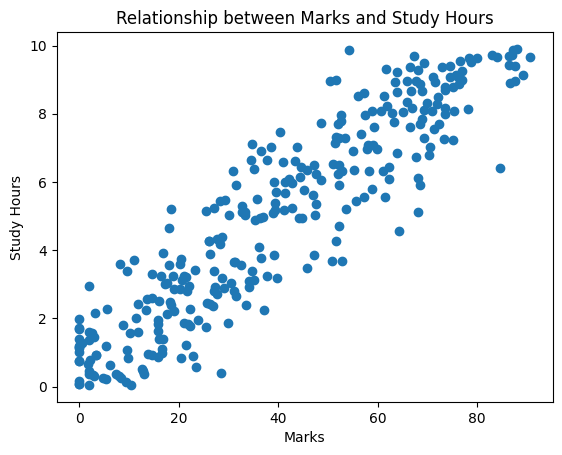

In [ ]:
x = data['marks']
y = data['study_hours']

plt.scatter(x, y)
plt.xlabel('Marks')
plt.ylabel('Study Hours')
plt.title('Relationship between Marks and Study Hours')

plt.show()

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2)

In [ ]:
train_x.head()

4      10.11
281    34.73
59     18.92
206     0.00
199    52.67
Name: marks, dtype: float64

In [ ]:
train_x.shape

(240,)

In [ ]:
train_y.shape

(240,)

In [1]:
import pickle
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load data
data = pd.read_csv('student_data.csv')

X = data[['study_hours', 'sleep_hours', 'mobile_usage_hours']]
y = data['pass_fail']

# Train model
model = LogisticRegression()
model.fit(X, y)

# Save model
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [2]:
data.head()

,study_hours,sleep_hours,mobile_usage_hours,marks,pass_fail
0,3.75,7.40,5.20,20.48,0
1,9.51,6.86,3.04,78.85,1
2,7.32,7.98,5.86,51.55,1
3,5.99,9.62,7.02,39.09,1
4,1.56,8.40,6.46,10.11,0


In [3]:

import pandas as pd
import pickle
from sklearn.ensemble import RandomForestRegressor

# Load data
data = pd.read_csv('student_data.csv')

X = data[['study_hours', 'sleep_hours', 'mobile_usage_hours']]
y = data['marks']

# Better model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X, y)

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Better model saved!")

✅ Better model saved!


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load data
data = pd.read_csv('student_data.csv')

X = data[['study_hours', 'sleep_hours', 'mobile_usage_hours']]
y = data['marks']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

# Evaluate
print("📉 Linear Regression")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\n🌳 Random Forest")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))

📉 Linear Regression
R2 Score: 0.8365639791219545
MAE: 7.951991028304006

🌳 Random Forest
R2 Score: 0.8050353427920587
MAE: 8.831959999999997


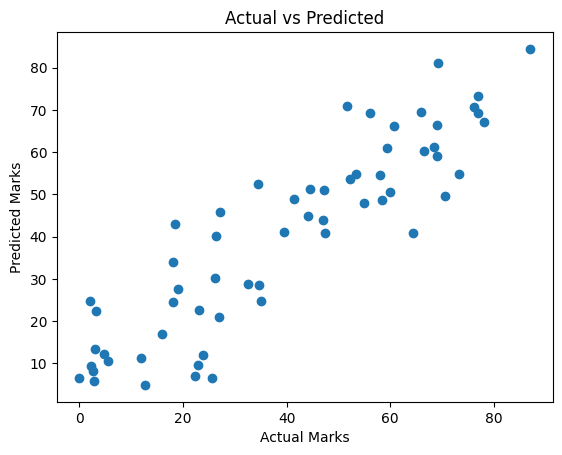

In [5]:
import matplotlib.pyplot as plt

plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

plt.show()

In [6]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("✅ Best model saved (Random Forest)")

✅ Best model saved (Random Forest)


In [8]:
data.head()

,study_hours,sleep_hours,mobile_usage_hours,marks,pass_fail
0,3.75,7.40,5.20,20.48,0
1,9.51,6.86,3.04,78.85,1
2,7.32,7.98,5.86,51.55,1
3,5.99,9.62,7.02,39.09,1
4,1.56,8.40,6.46,10.11,0
